In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score,root_mean_squared_error

import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Input

In [ ]:
df = pd.read_csv('Admission_Predict_Ver1.1.csv') #<-- Load this Admission prediction dataset
# This dataset is the newer version of the original dataset
# It contains features that include factors that affect chance of admit to predict admission

In [ ]:
df.head() # <-- Skim head

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [ ]:
df.shape # < -- Check shape

(500, 9)

In [ ]:
df.info() # <-- Check for any null values

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         500 non-null    int64  
 1   GRE Score          500 non-null    int64  
 2   TOEFL Score        500 non-null    int64  
 3   University Rating  500 non-null    int64  
 4   SOP                500 non-null    float64
 5   LOR                500 non-null    float64
 6   CGPA               500 non-null    float64
 7   Research           500 non-null    int64  
 8   Chance of Admit    500 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 35.3 KB


In [103]:
df.duplicated().sum() # <--Check for any dupicate entry

np.int64(0)

In [79]:
# Observations :
#   Serial No is obviously just the index so we will just remove it 
#   GRE Scale is large in scale and we have to normalize them so that our ann model can learn the parameters easily.
#       So we will use here MinMixScaler instead because there is a tight upper and lower bound here .

In [80]:
df = df.drop(columns=['Serial No.'])

In [81]:
df.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


In [82]:
# Split the dataset into two

In [83]:
X,y = df.iloc[:,0:-1],df.iloc[:,-1]

In [84]:
X.shape,y.shape

((500, 7), (500,))

In [85]:
X.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research
0,337,118,4,4.5,4.5,9.65,1
1,324,107,4,4.0,4.5,8.87,1
2,316,104,3,3.0,3.5,8.00,1
3,322,110,3,3.5,2.5,8.67,1
4,314,103,2,2.0,3.0,8.21,0


In [86]:
y.head()

0    0.92
1    0.76
2    0.72
3    0.80
4    0.65
Name: Chance of Admit , dtype: float64

In [87]:
# Then split into training and testing set with appropriate proportions
X_train ,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [88]:
# Now scale these value using  MinMaxScaler

In [89]:
scaler = MinMaxScaler()

# Always fit on training set beforehand and then only apply transform to both especially test set to avoid data leaks
scaler.fit(X_train)

X_train_scalled = scaler.transform(X_train)
X_test_scalled = scaler.transform(X_test)

In [90]:
X_train_scalled[:5] # Skim the top5 values

array([[0.62      , 0.67857143, 0.5       , 0.625     , 0.71428571,
        0.65064103, 1.        ],
       [0.52      , 0.67857143, 0.75      , 0.75      , 1.        ,
        0.55769231, 0.        ],
       [0.26      , 0.35714286, 0.5       , 0.625     , 0.42857143,
        0.54487179, 0.        ],
       [0.48      , 0.53571429, 0.25      , 0.375     , 0.71428571,
        0.47115385, 0.        ],
       [0.36      , 0.5       , 0.5       , 0.625     , 0.28571429,
        0.45192308, 1.        ]])

In [91]:
X_test_scalled[:5] # Skim the top5 values

array([[0.88      , 0.85714286, 0.75      , 0.75      , 0.57142857,
        0.87820513, 1.        ],
       [0.48      , 0.57142857, 0.75      , 0.875     , 0.71428571,
        0.71794872, 1.        ],
       [0.5       , 0.46428571, 0.25      , 0.25      , 0.28571429,
        0.2724359 , 0.        ],
       [0.44      , 0.60714286, 0.5       , 0.5       , 0.42857143,
        0.60576923, 0.        ],
       [0.72      , 0.71428571, 0.5       , 0.625     , 0.42857143,
        0.72115385, 1.        ]])

In [92]:
# Build the model
model = Sequential()
model.add(Input(shape=(X_train_scalled.shape[1],)))
model.add(Dense(7,activation='relu'))
model.add(Dense(7,activation='relu'))
model.add(Dense(1,activation='linear'))

In [ ]:
model.summary() # < -- Check model summary 

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                │ (None, 7)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 7)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 120 (480.00 B)

 Trainable params: 120 (480.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile model and add loss and optimizer algorithm for the neural network
model.compile(
                loss='mean_squared_error',
                optimizer='Adam'
)

In [ ]:
# Train and Experiment the model on differnt hyperparamaters
history = model.fit(
            X_train_scalled,
            y_train,
            epochs = 100,
            validation_split = 0.2
)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - loss: 0.3509 - val_loss: 0.2988
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.2388 - val_loss: 0.1720
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1332 - val_loss: 0.0780
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0611 - val_loss: 0.0312
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0319 - val_loss: 0.0238
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0293 - val_loss: 0.0257
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0282 - val_loss: 0.0221
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0250 - val_loss: 0.0195
Epoch 9/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0226 - val_loss: 0.0178
Epoch 10/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0204 - val_loss: 0.0163
Epoch 11/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0180 - val_loss: 0.0151
Epoch 12/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step

In [ ]:
y_pred = model.predict(X_test_scalled) # Store prediction values

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


In [97]:
y_pred[:10]

array([[0.90699464],
       [0.7752844 ],
       [0.60973144],
       [0.7011948 ],
       [0.8185667 ],
       [0.8440326 ],
       [0.47905433],
       [0.66497207],
       [0.7939098 ],
       [0.8152682 ]], dtype=float32)

In [ ]:
r2_score(y_test,y_pred) # Calculate the r2_score of the model

0.761403156264039

In [ ]:
# Model Results :
'''
Setting 1 : 

model = Sequential()
model.add(Input(shape=(X_train_scalled.shape[1],)))
model.add(Dense(7,activation='relu'))
model.add(Dense(1,activation='linear'))

history = model.fit(
            X_train_scalled,
            y_train,
            epochs = 10,
            validation_split = 0.2
)

Evaluation : In this the model had a negative r2_score of -1.7 something which was worse than a horizontal line

Setting 2 : 

model = Sequential()
model.add(Input(shape=(X_train_scalled.shape[1],)))
model.add(Dense(7,activation='relu'))
model.add(Dense(7,activation='relu'))
model.add(Dense(1,activation='linear'))

history = model.fit(
            X_train_scalled,
            y_train,
            epochs = 100,
            validation_split = 0.2
)

Evaluation : Model finally was able to capture patterns with increasing complxity and got an r2_score of 0.761403156264039
'''

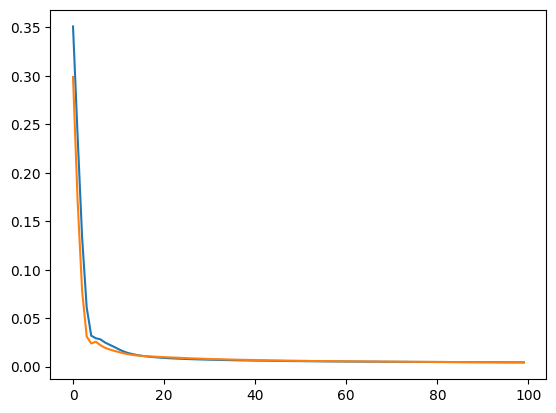

In [101]:
# Plot the loss and val_loss across epochs
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.show()